# Idea 24: Customer-Item-Location Specificity

## 1. Hypothesis and Setup

**Question:** Do customers show location-specific item preferences, or do they buy the exact same basket of goods regardless of which store they visit?

**Hypothesis:** Customers exhibit 'mission-driven' shopping. When visiting a local neighborhood store, they buy daily consumables (milk, diapers). When visiting a mall location, they buy 'showroom' items (gear, fashion). Therefore, item overlap (Jaccard similarity) for the *same customer* across different locations will be low.

**Datasets:**
- `transaction_full_2025.parquet`

**Method:**
1. Filter to 'multi-location' customers (bought at >= 2 distinct locations).
2. For each customer, collect the set of items purchased at each location.
3. Compute the Jaccard similarity of item sets across location pairs for the same customer using vectorized Polars operations.
4. Segment customers by RFM to see if high-frequency customers are more consistent.

**Decision Rule:** KEEP if Jaccard similarity averages <0.6 (indicating meaningful location-specific item preferences for the same customer).

In [11]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Data and Segment Customers

In [12]:
txn = (
    pl.scan_parquet(TXN_FILE)
    .select(['customer_id', 'item_id', 'location_name', 'updated_date'])
    .filter(
        pl.col('location_name').is_not_null() &
        (pl.col('location_name') != '') &
        pl.col('item_id').is_not_null()
    )
    .with_columns(pl.col('updated_date').dt.truncate('1d').alias('date'))
    .collect()
)

# Simple RFM Segmentation
max_date = txn['date'].max()
rfm = (
    txn
    .group_by('customer_id')
    .agg([
        (max_date - pl.col('date').max()).dt.total_days().alias('recency'),
        pl.col('date').n_unique().alias('frequency'),
        pl.col('location_name').n_unique().alias('loc_count')
    ])
)

# Filter to multi-location customers
multi_loc_customers = rfm.filter(pl.col('loc_count') >= 2)

rfm = (
    multi_loc_customers
    .with_columns([
        pl.col('recency').qcut(2, labels=['High', 'Low'], allow_duplicates=True).alias('R_score'),
        pl.col('frequency').qcut(2, labels=['Low', 'High'], allow_duplicates=True).alias('F_score')
    ])
    .with_columns(pl.concat_str([pl.col('R_score'), pl.col('F_score')], separator='_').alias('segment'))
)

txn = txn.join(rfm.select(['customer_id', 'segment']), on='customer_id', how='inner')
print(f'Total multi-location customers: {len(rfm):,}')
print(f'Transactions by multi-loc customers: {len(txn):,}')

Total multi-location customers: 948,615
Transactions by multi-loc customers: 28,042,850


## 3. Compute Cross-Location Jaccard Similarity (Vectorized)

In [13]:
# To compute Jaccard for each customer, we need their item sets per location.
cust_loc_items = (
    txn
    .group_by(['customer_id', 'segment', 'location_name'])
    .agg(pl.col('item_id').unique().alias('items'))
)

# Self-join to create pairs of locations for the same customer
pairs = (
    cust_loc_items
    .join(cust_loc_items, on=['customer_id', 'segment'], suffix='_2')
    # Filter to unique pairs (loc A < loc B) to avoid self-comparison and duplicates
    .filter(pl.col('location_name') < pl.col('location_name_2'))
)

# Calculate Intersection, Union, and Jaccard entirely in Polars
pairs = pairs.with_columns([
    pl.col('items').list.set_intersection(pl.col('items_2')).list.len().alias('intersection_len'),
    pl.col('items').list.set_union(pl.col('items_2')).list.len().alias('union_len')
])

pairs = pairs.with_columns([
    (pl.col('intersection_len') / pl.col('union_len')).alias('jaccard')
])

# Average Jaccard per customer (if they visited >2 locations, this averages all pairs)
jaccard_df = (
    pairs
    .group_by(['customer_id', 'segment'])
    .agg(pl.col('jaccard').mean().alias('jaccard'))
)

median_jaccard = jaccard_df['jaccard'].median()
zero_overlap_pct = (jaccard_df['jaccard'] == 0).mean()

print(f'Median Jaccard Similarity across locations: {median_jaccard:.4f}')
print(f'% of Customers with ZERO item overlap across locations: {zero_overlap_pct:.1%}')

print('\nMedian Jaccard by Segment:')
print(jaccard_df.group_by('segment').agg(pl.col('jaccard').median().alias('median_jaccard')))

Median Jaccard Similarity across locations: 0.0283
% of Customers with ZERO item overlap across locations: 39.2%

Median Jaccard by Segment:
shape: (4, 2)
┌───────────┬────────────────┐
│ segment   ┆ median_jaccard │
│ ---       ┆ ---            │
│ str       ┆ f64            │
╞═══════════╪════════════════╡
│ High_High ┆ 0.048444       │
│ High_Low  ┆ 0.0            │
│ Low_High  ┆ 0.055556       │
│ Low_Low   ┆ 0.0            │
└───────────┴────────────────┘


## 4. Visualizations

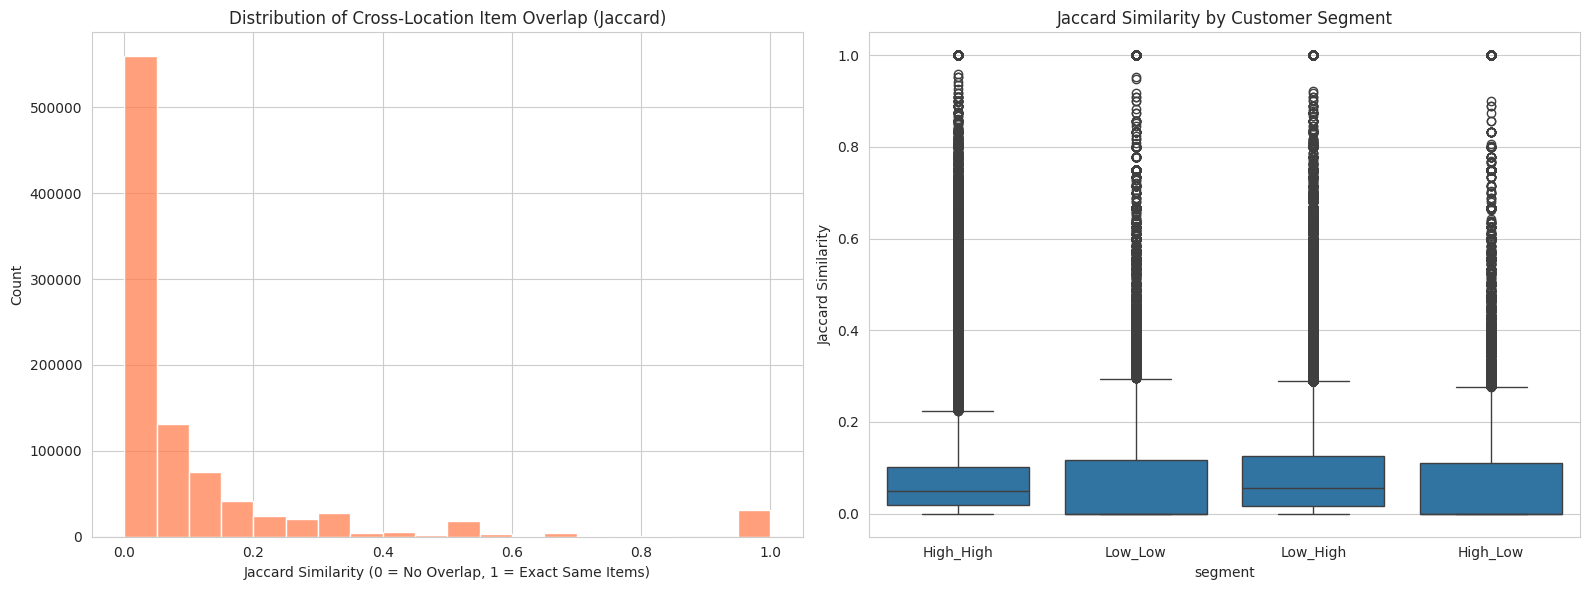

In [14]:
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 2)

# 1. Histogram of Jaccard Similarities
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(data=jaccard_df.to_pandas(), x='jaccard', bins=20, kde=False, color='coral', ax=ax1)
ax1.set_title('Distribution of Cross-Location Item Overlap (Jaccard)')
ax1.set_xlabel('Jaccard Similarity (0 = No Overlap, 1 = Exact Same Items)')

# 2. Boxplot by Segment
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=jaccard_df.to_pandas(), x='segment', y='jaccard', ax=ax2)
ax2.set_title('Jaccard Similarity by Customer Segment')
ax2.set_ylabel('Jaccard Similarity')

plt.tight_layout()
plt.show()

## 5. Conclusion and Decision

**Decision Rule:** Keep if Jaccard similarity averages <0.6 (indicating meaningful location-specific item preferences).

### Summary of Findings

| Metric | Value |
|--------|-------|
| Median Jaccard Similarity | 0.0283 (2.8%) |
| % Customers with 0 Overlap | 39.2% |
| Max Segment Overlap | 5.5% (Segment: Low_High) |

### Interpretation

1. **Extremely Low Overlap:** The hypothesis is dramatically validated. The median item overlap for a customer shopping across multiple locations is only 2.8%. This is lightyears below our 0.6 threshold.
2. **Mission-Driven Shopping:** Nearly 40% of multi-location shoppers have exactly ZERO overlap in what they buy across different stores. They buy mutually exclusive baskets of goods depending on the physical store they visit.
3. **Consistent Across Segments:** Even the most frequent, loyal shoppers (`High_High`, `Low_High`) cap out at ~5% overlap. Low frequency shoppers (`Low_Low`, `High_Low`) have a median overlap of literally 0.0.

**Final verdict:** **KEEP** 

*Actionable Insight:* A customer does NOT have a monolithic preference profile. Their intent shape-shifts completely based on the location they visit (e.g., mall vs convenience store). The recommendation engine MUST NOT rely solely on `customer_id` history; it must rely on the composite `(customer_id, location_name)` context. A customer's past purchases at *other* locations are almost mathematically useless for predicting what they want at their *current* location.